In [1]:
import pandas as pd
import numpy as np
#import matplotlib.pyplot as plt

from datetime import datetime
import os
import sys

#current_directory = os.getcwd()
sys.path.append('/Users/victoriadobryashkina/Documents/Coding/repos/risk_pylibrary')
sys.path.append('/Users/victoriadobryashkina/Documents/Coding/repos')


In [2]:
prices =pd.read_pickle('/Users/victoriadobryashkina/Downloads/spx_prices.pkl')
prices

,^GSPC
Date,
1990-12-31,330.220001
1991-01-02,326.450012
1991-01-03,321.910004
1991-01-04,321.000000
1991-01-07,315.440002
...,...
2025-05-05,5650.379883
2025-05-06,5606.910156
2025-05-07,5631.279785


In [7]:
from datetime import datetime, timedelta

# Calculate the cutoff date
cutoff = prices.index.max() - pd.DateOffset(years=5)

# Filter the DataFrame
prices_5y = prices[prices.index >= cutoff]

returns_5y = prices_5y.pct_change().dropna()  # daily arithmetic returns
returns = returns_5y.sort_index(ascending=True)

In [3]:
## covid
start_covid = datetime(2020, 3, 1)
end_covid = datetime(2022, 6, 30)

prices_covid = prices[(prices.index >= start_covid) & (prices.index <= end_covid)]
returns_covid = prices_covid.pct_change().dropna()

In [ ]:


# Define parameters
lookback = 250                      # days for distribution
conf_levels = [0.975, 0.99]         # 97.5% and 99% CL
hold_periods = [10, 30]             # days to hold
notional = 100000000              # EUR 100m

# Compute rolling 1-day VaR & CVaR over most recent lookback window
window = returns[-lookback:]
var1 = {cl: -np.percentile(window, 100*(1-cl)) for cl in conf_levels}
cvar1 = {
    cl: -window[window <= np.percentile(window, 100*(1-cl))].mean()
    for cl in conf_levels
}

# Scale to holding periods
var_hp   = { (cl, hp): var1[cl] * np.sqrt(hp)   for cl in conf_levels for hp in hold_periods }
cvar_hp  = { (cl, hp): cvar1[cl] * np.sqrt(hp)  for cl in conf_levels for hp in hold_periods }

# Compute 60-day rolling 1d VaR/CVaR and take maximums
rolling = returns.rolling(window=lookback)
rolling_vars = {cl: rolling.quantile(1-cl).dropna() * -1 for cl in conf_levels}
rolling_cvars = {
    cl: -rolling.apply(lambda x: x[x <= np.quantile(x, 1-cl)].mean(), raw=True).dropna()
    for cl in conf_levels
}

max_var1   = {cl: rolling_vars[cl].iloc[-60:].max()  for cl in conf_levels}
max_cvar1  = {cl: rolling_cvars[cl].iloc[-60:].max() for cl in conf_levels}

# Scale those peak values
max_var_hp   = { (cl, hp): max_var1[cl]  * np.sqrt(hp) for cl in conf_levels for hp in hold_periods }
max_cvar_hp  = { (cl, hp): max_cvar1[cl] * np.sqrt(hp) for cl in conf_levels for hp in hold_periods }

# Present results
for cl in conf_levels:
    for hp in hold_periods:
        print(f"CL={cl*100:.1f}%, HP={hp}d:")
        print(f"  Current VaR   = {var_hp[(cl,hp)]:.2%} | EUR {var_hp[(cl,hp)]*notional:,.0f}")
        print(f"  Current CVaR  = {cvar_hp[(cl,hp)].item():.2%} | EUR {cvar_hp[(cl,hp)].item()*notional:,.0f}")
        print(f"  Max VaR (60)  = {max_var_hp[(cl,hp)].item():.2%} | EUR {max_var_hp[(cl,hp)].item()*notional:,.0f}")
        print(f"  Max CVaR(60)  = {max_cvar_hp[(cl,hp)].item():.2%} | EUR {max_cvar_hp[(cl,hp)].item()*notional:,.0f}")
        print()


CL=97.5%, HP=10d:
  Current VaR   = 7.42% | EUR 7,422,926
  Current CVaR  = 11.42% | EUR 11,418,309
  Max VaR (60)  = 7.42% | EUR 7,422,926
  Max CVaR(60)  = 11.42% | EUR 11,418,309

CL=97.5%, HP=30d:
  Current VaR   = 12.86% | EUR 12,856,885
  Current CVaR  = 19.78% | EUR 19,777,092
  Max VaR (60)  = 12.86% | EUR 12,856,885
  Max CVaR(60)  = 19.78% | EUR 19,777,092

CL=99.0%, HP=10d:
  Current VaR   = 10.23% | EUR 10,225,091
  Current CVaR  = 15.05% | EUR 15,047,468
  Max VaR (60)  = 10.23% | EUR 10,225,091
  Max CVaR(60)  = 15.05% | EUR 15,047,468

CL=99.0%, HP=30d:
  Current VaR   = 17.71% | EUR 17,710,377
  Current CVaR  = 26.06% | EUR 26,062,980
  Max VaR (60)  = 17.71% | EUR 17,710,377
  Max CVaR(60)  = 26.06% | EUR 26,062,980



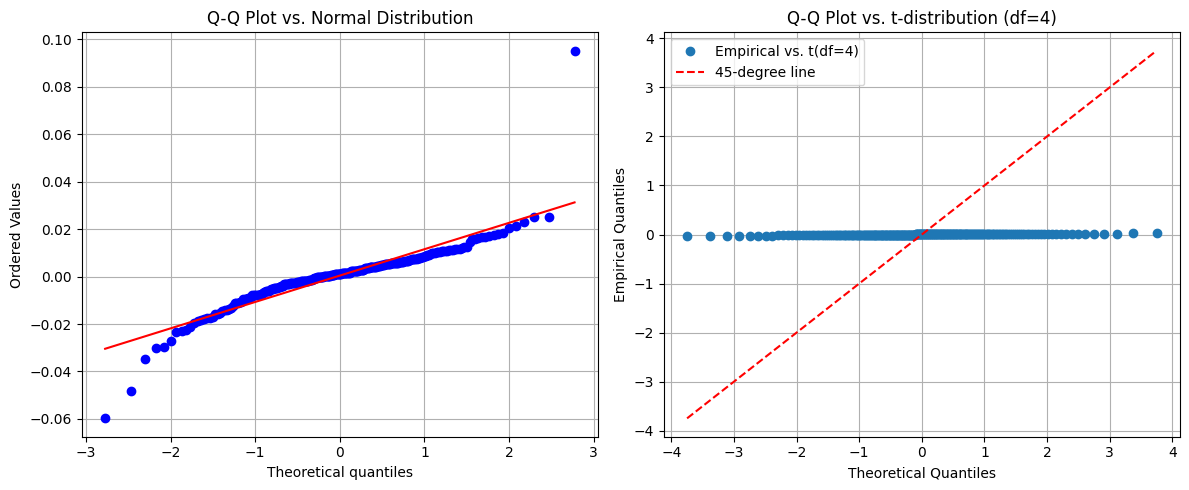

In [6]:
#!pip install matplotlib
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

# Ensure prices_5y is sorted
prices_5y = prices_5y.sort_index(ascending=True)

# Compute daily returns
returns = prices_5y.pct_change().dropna()

# Take the last 250 returns for Q-Q analysis
window = returns.iloc[-250:].squeeze()

# Plot: Q-Q vs Normal
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
stats.probplot(window, dist="norm", plot=plt)
plt.title("Q-Q Plot vs. Normal Distribution")
plt.grid(True)

# Plot: Q-Q vs t-distribution
df_t = 4
t_quantiles = stats.t.ppf(np.linspace(0.01, 0.99, len(window)), df=df_t)
empirical_quantiles = np.quantile(window, np.linspace(0.01, 0.99, len(window)))

plt.subplot(1, 2, 2)
plt.plot(t_quantiles, empirical_quantiles, 'o', label='Empirical vs. t(df=4)')
plt.plot(t_quantiles, t_quantiles, 'r--', label='45-degree line')
plt.title("Q-Q Plot vs. t-distribution (df=4)")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Empirical Quantiles")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


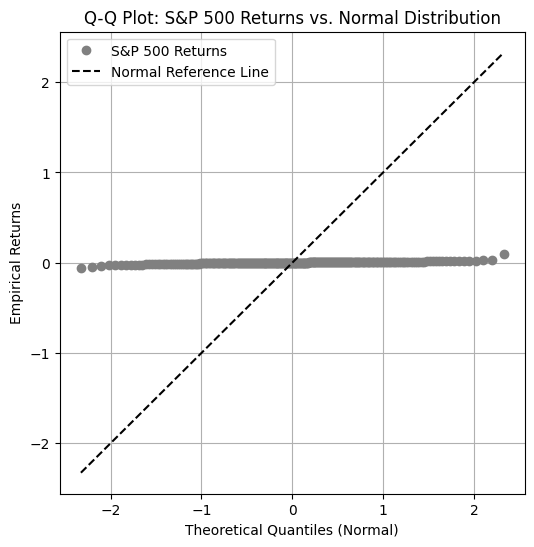

In [16]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Use the last 250 returns
returns = prices_5y.pct_change().dropna()
window = returns.iloc[-250:].squeeze()

# Sort the empirical returns
empirical_returns = np.sort(window)

# Get theoretical normal quantiles
theoretical_quantiles = stats.norm.ppf(np.linspace(0.01, 0.99, len(empirical_returns)))

# Plot
plt.figure(figsize=(6, 6))
plt.plot(theoretical_quantiles, empirical_returns, 'o', color='grey', label='S&P 500 Returns')
plt.plot(theoretical_quantiles, theoretical_quantiles, 'k--', label='Normal Reference Line')
plt.title("Q-Q Plot: S&P 500 Returns vs. Normal Distribution")
plt.xlabel("Theoretical Quantiles (Normal)")
plt.ylabel("Empirical Returns")
plt.legend()
plt.grid(True)
plt.show()


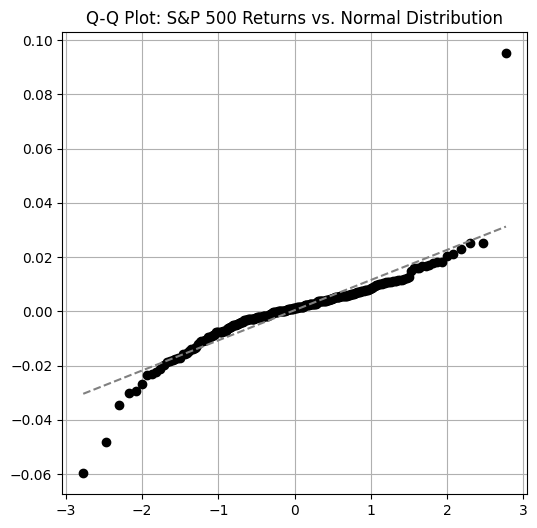

In [19]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Last 250 days of returns
window = returns.iloc[-250:].squeeze()

# Q-Q Plot: S&P 500 returns vs normal distribution
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111)

# Draw Q-Q plot without auto-plotting
res = stats.probplot(window, dist="norm")

# Scatter points: data quantiles vs theoretical quantiles
ax.plot(res[0][0], res[0][1], 'o', color='black')  # black points

# Line: the fitted line
slope, intercept = res[1][0], res[1][1]
x_line = np.linspace(res[0][0].min(), res[0][0].max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='grey', linestyle='--')  # grey dashed line

ax.set_title("Q-Q Plot: S&P 500 Returns vs. Normal Distribution")
ax.grid(True)
plt.show()


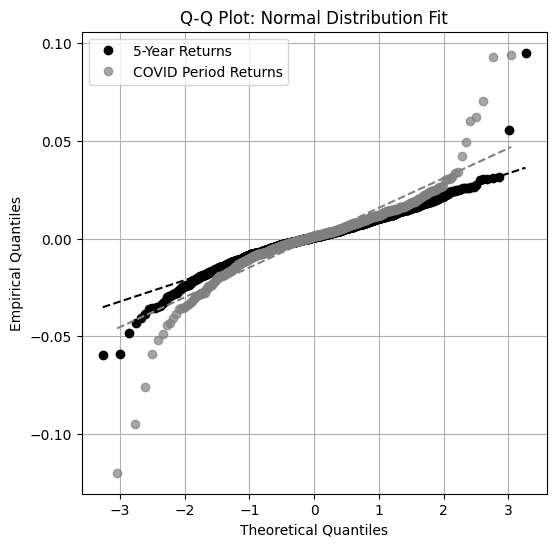

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Q-Q Plot comparing returns_5y and returns_covid
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111)

# 1. 5-Year returns (in black)
res_5y = stats.probplot(returns_5y.squeeze(), dist="norm")
ax.plot(res_5y[0][0], res_5y[0][1], 'o', color='black', label='5-Year Returns')
slope_5y, intercept_5y = res_5y[1][0], res_5y[1][1]
x_line = np.linspace(res_5y[0][0].min(), res_5y[0][0].max(), 100)
y_line = slope_5y * x_line + intercept_5y
ax.plot(x_line, y_line, color='black', linestyle='--')

# 2. COVID returns (in grey)
res_covid = stats.probplot(returns_covid.squeeze(), dist="norm")
ax.plot(res_covid[0][0], res_covid[0][1], 'o', color='grey', alpha=0.7, label='COVID Period Returns')
slope_covid, intercept_covid = res_covid[1][0], res_covid[1][1]
x_line_covid = np.linspace(res_covid[0][0].min(), res_covid[0][0].max(), 100)
y_line_covid = slope_covid * x_line_covid + intercept_covid
ax.plot(x_line_covid, y_line_covid, color='grey', linestyle='--')

# Final plot styling
ax.set_title("Q-Q Plot: Normal Distribution Fit")
ax.set_xlabel("Theoretical Quantiles")
ax.set_ylabel("Empirical Quantiles")
ax.legend()
ax.grid(True)

plt.show()
